# 8 二叉树

## 8.1 二叉树的中序遍历

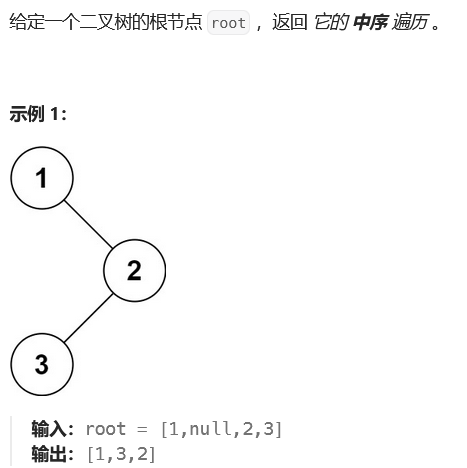

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def inorderTraversal(self, root: Optional[TreeNode]) -> List[int]:
        # 递归法
        res = []
        def dfs(node):
            if not node:
                return
            dfs(node.left)
            res.append(node.val)
            dfs(node.right)
        dfs(root)
        return res

## 8.2 二叉树的最大深度

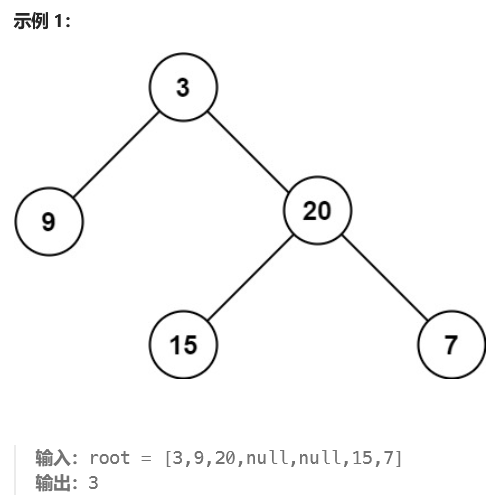

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def maxDepth(self, root: Optional[TreeNode]) -> int:
        if not root:
            return 0
        left_depth = self.maxDepth(root.left)
        right_depth = self.maxDepth(root.right)
        return 1 + max(left_depth,right_depth)

## 8.3 翻转二叉树

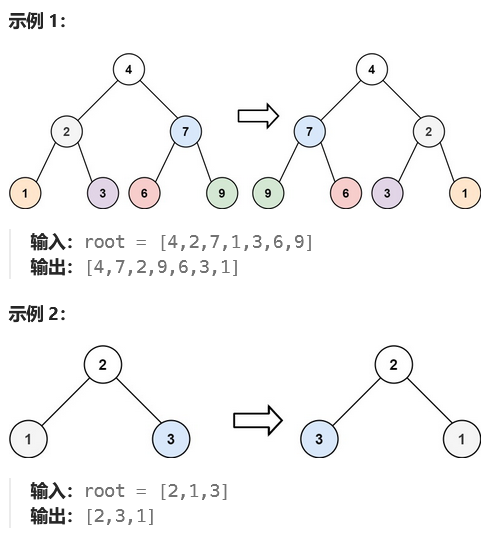

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def invertTree(self, root: Optional[TreeNode]) -> Optional[TreeNode]:
        if not root:
            return None
        
        root.left,root.right = root.right,root.left
        self.invertTree(root.left)
        self.invertTree(root.right)
        return root

## 8.4 对称二叉树

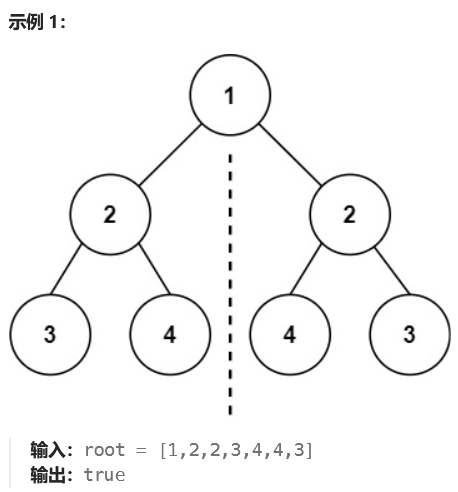

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def isSymmetric(self, root: Optional[TreeNode]) -> bool:
        # 空树直接对称
        if not root:
            return True
        # 检查左右子树是否镜像
        return self.isMirror(root.left, root.right)
    
    def isMirror(self, left: TreeNode, right: TreeNode) -> bool:
        # 两个节点都为空 → 对称
        if not left and not right:
            return True
        # 一个空一个非空 → 不对称
        if not left or not right:
            return False
        # 值相等 + 左左对右右 + 左右对右左
        return (left.val == right.val 
                and self.isMirror(left.left, right.right) 
                and self.isMirror(left.right, right.left))

## 8.5 二叉树的直径

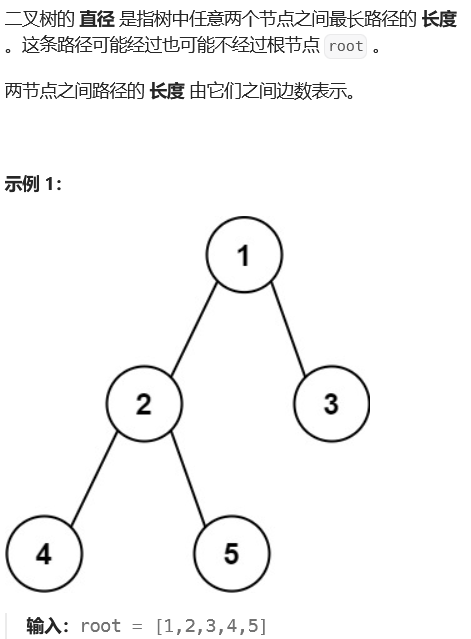

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def diameterOfBinaryTree(self, root: Optional[TreeNode]) -> int:
        self.max_d = 0
        
        def dfs(node):
            if not node:
                return 0
            # 后序：先左右
            left_depth = dfs(node.left)
            right_depth = dfs(node.right)
            
            # 更新以当前节点为顶点的直径
            self.max_d = max(self.max_d, left_depth + right_depth)
            
            # 返回当前节点的最大深度
            return max(left_depth, right_depth) + 1
        
        dfs(root)
        return self.max_d

## 8.6 二叉树的层序遍历

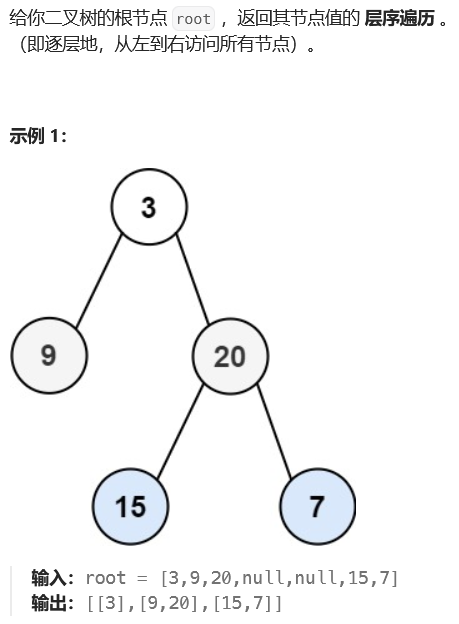

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def levelOrder(self, root: TreeNode):
        res = []
        def dfs(node, depth):
            if not node:
                return
            # 首次到这一层，新建一层列表
            if len(res) == depth:
                res.append([])
            res[depth].append(node.val)
            dfs(node.left, depth + 1)
            dfs(node.right, depth + 1)
        dfs(root, 0)
        return res
            

## 8.7 将有序数组转换为平衡二叉搜索树

- 二叉搜索树 BST：
左子树所有值 < 根节点值 < 右子树所有值。
- 平衡：
左右子树的高度差不超过 1。

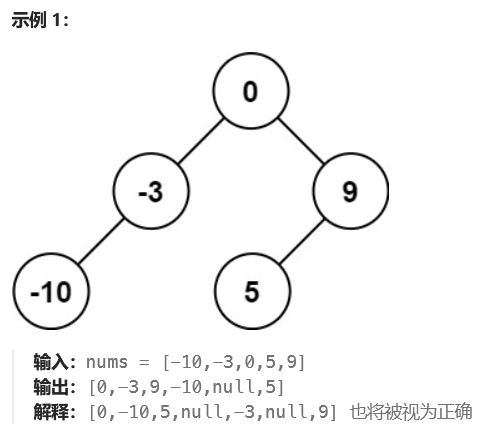

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def sortedArrayToBST(self, nums: List[int]) -> Optional[TreeNode]:
        if not nums:
            return None
        mid = len(nums)//2
        root = TreeNode(nums[mid])
        root.left = self.sortedArrayToBST(nums[:mid])
        root.right = self.sortedArrayToBST(nums[mid+1:])
        return root

## 8.8 验证二叉搜索树

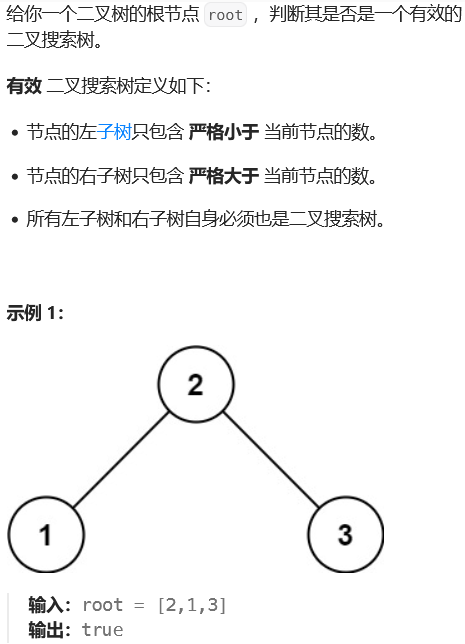

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def isValidBST(self, root: TreeNode) -> bool:
        res = []
        def inorder(node):
            if not node:
                return
            inorder(node.left)
            res.append(node.val)
            inorder(node.right)
        inorder(root)
        # 严格升序
        for i in range(1, len(res)):
            if res[i] <= res[i-1]:
                return False
        return True
        

## 8.9 二叉搜索树中第K小的元素

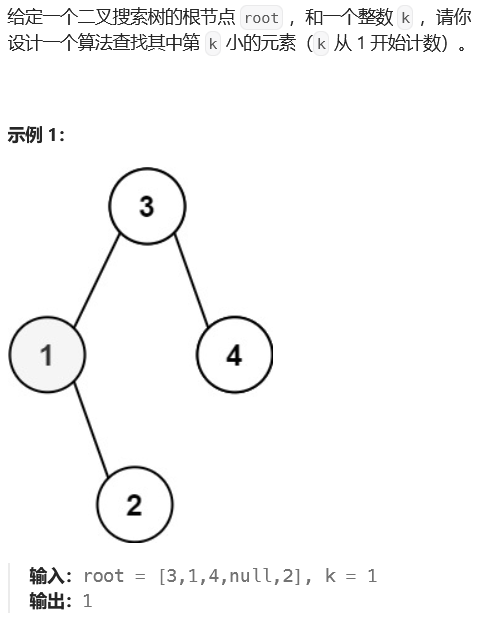

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def kthSmallest(self, root: Optional[TreeNode], k: int) -> int:
        res = []

        def dfs(node):
            if not node:
                return
            dfs(node.left)
            res.append(node.val)
            dfs(node.right)
        dfs(root)
        return res[k-1]

## 8.10 二叉树的右视图

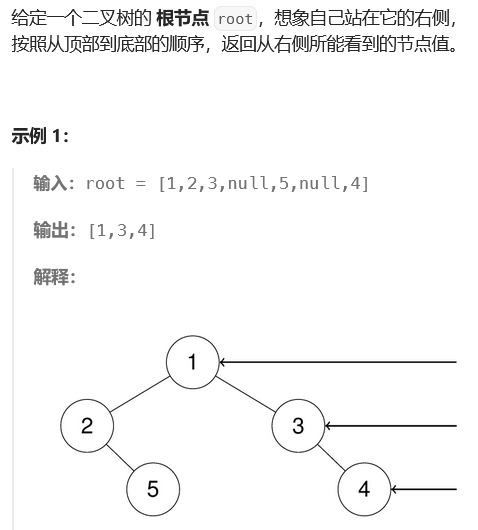

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def rightSideView(self, root: Optional[TreeNode]) -> List[int]:
        res = []
        def dfs(node, depth):
            if not node:
                return
            # 第一次到达该深度，就是右视图
            if depth == len(res):
                res.append(node.val)
            # 先右后左
            dfs(node.right, depth + 1)
            dfs(node.left, depth + 1)
        dfs(root, 0)
        return res

## 8.11 将二叉树展开为链表

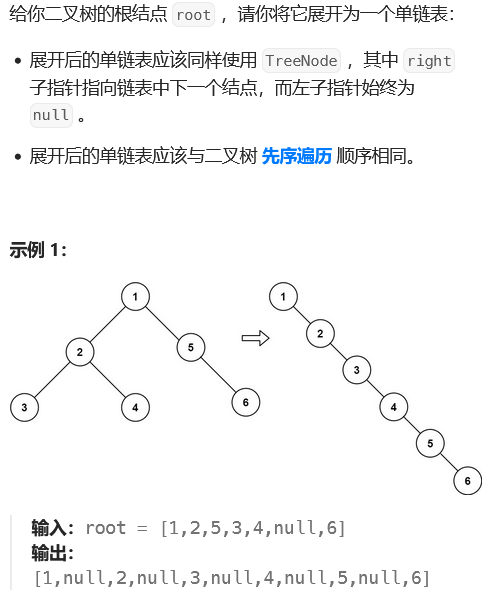

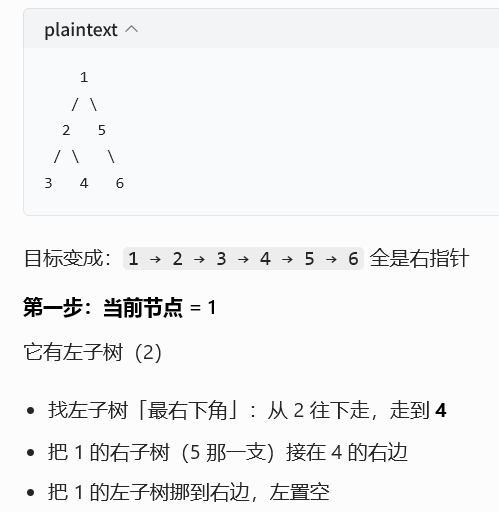

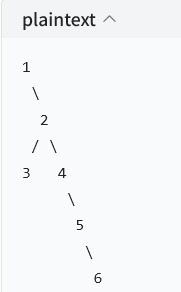

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def flatten(self, root: Optional[TreeNode]) -> None:
        """
        Do not return anything, modify root in-place instead.
        """
        cur = root
        while cur:
            # 如果有左子树，才需要处理
            if cur.left:
                # 找到左子树的最右节点
                pre = cur.left
                while pre.right:
                    pre = pre.right
                
                # 步骤1：把当前节点的右子树接到最右节点的右孩子
                pre.right = cur.right
                # 步骤2：把左子树移到右边
                cur.right = cur.left
                # 步骤3：左子树置空
                cur.left = None
            
            # 处理下一个节点（已经移到右边了）
            cur = cur.right

## 8.12 从前序与中序遍历序列构造二叉树

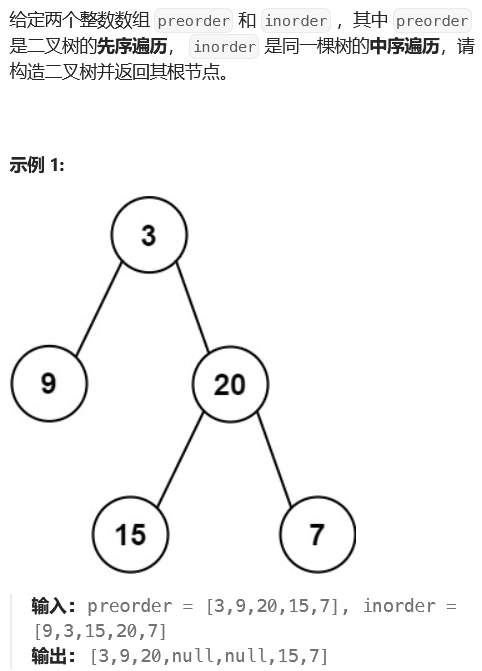

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def buildTree(self, preorder: List[int], inorder: List[int]) -> Optional[TreeNode]:
        if not preorder or not inorder:
            return None
        
        # 前序第一个为根
        root_val = preorder[0]
        root = TreeNode(root_val)
        
        # 中序找根的下标
        idx = inorder.index(root_val)
        
        # 递归构造左、右子树
        # 左子树：前序[1:idx+1]，中序[0:idx]
        root.left = self.buildTree(preorder[1:idx+1], inorder[:idx])
        # 右子树：前序[idx+1:]，中序[idx+1:]
        root.right = self.buildTree(preorder[idx+1:], inorder[idx+1:])
        
        return root

## 8.13 路径总和三

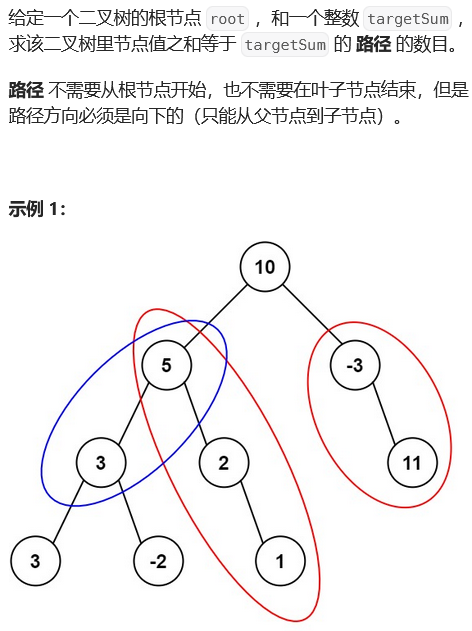

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def pathSum(self, root: Optional[TreeNode], targetSum: int) -> int:
        from collections import defaultdict
        # 前缀和字典：key=前缀和，value=出现次数
        prefix = defaultdict(int)
        # 关键：前缀和为0出现1次（处理从根节点开始的路径）
        prefix[0] = 1
        
        def dfs(node, curr_sum):
            if not node:
                return 0
            # 当前路径和
            curr_sum += node.val
            # 符合条件的路径数 = 前缀和中 (curr_sum - target) 出现的次数
            res = prefix[curr_sum - targetSum]
            
            # 回溯：加入当前前缀和
            prefix[curr_sum] += 1
            
            # 递归左右子树
            res += dfs(node.left, curr_sum)
            res += dfs(node.right, curr_sum)
            
            # 回溯：恢复状态（核心！不影响其他分支）
            prefix[curr_sum] -= 1
            return res
        
        return dfs(root, 0)

## 8.14 二叉树的最近公共祖先

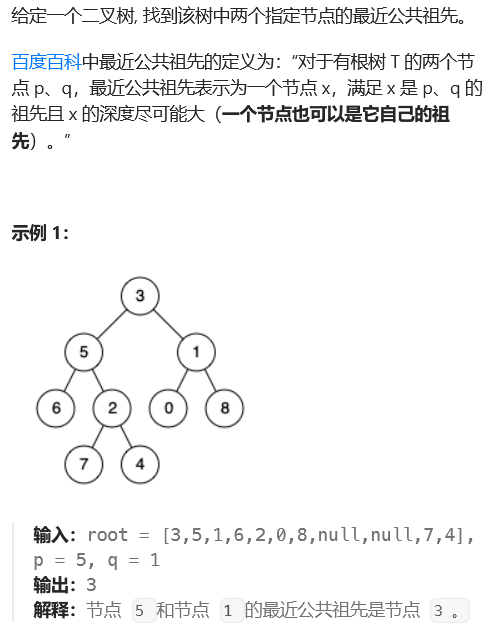

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, x):
#         self.val = x
#         self.left = None
#         self.right = None

class Solution:
    def lowestCommonAncestor(self, root: 'TreeNode', p: 'TreeNode', q: 'TreeNode') -> 'TreeNode':
        # 终止：空节点 / 遇到p或q，直接返回当前节点
        if not root or root == p or root == q:
            return root
        
        # 后序：先搜左、再搜右
        left = self.lowestCommonAncestor(root.left, p, q)
        right = self.lowestCommonAncestor(root.right, p, q)
        
        # 1. 左右都不为空 → 当前root就是LCA
        if left and right:
            return root
        # 2. 只有一边有值 → 往上传递有值的那一边
        return left if left else right

## 8.15 二叉树的最大路径和

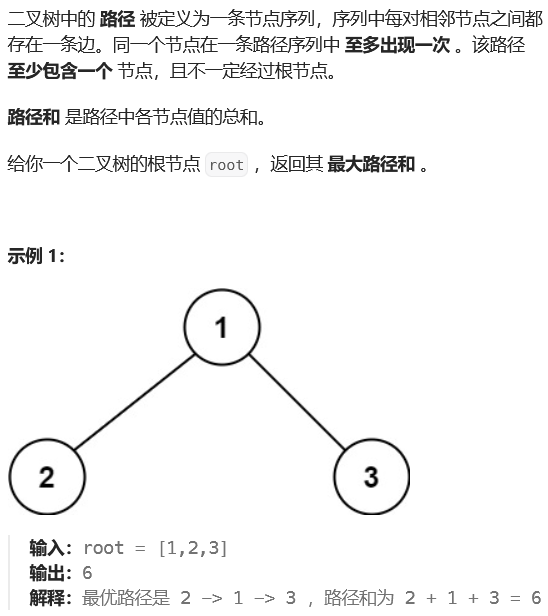

In [ ]:
# Definition for a binary tree node.
# class TreeNode:
#     def __init__(self, val=0, left=None, right=None):
#         self.val = val
#         self.left = left
#         self.right = right
class Solution:
    def maxPathSum(self, root: Optional[TreeNode]) -> int:
        # 初始化全局最大值为负无穷（应对全负数的情况）
        self.max_sum = float('-inf')
        
        def dfs(node):
            # 递归终止条件：空节点贡献为0
            if not node:
                return 0
            
            # 递归计算左右子树的最大贡献值（负数直接舍弃，取0）
            left = max(dfs(node.left), 0)
            right = max(dfs(node.right), 0)
            
            # 计算以当前节点为根的路径和（左+当前+右），更新全局最大值
            current_path = left + node.val + right
            self.max_sum = max(self.max_sum, current_path)
            
            # 返回当前节点能向上贡献的最大值（只能选左或右一条链）
            return node.val + max(left, right)
        
        # 启动递归
        dfs(root)
        return self.max_sum